# Proyecto Aprendizaje de Máquina - Clasificación de Textos por Década
## Parte 2: Deep Learning y Aumentación de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Integrantes

| Nombre                       | Código    | Correo electrónico           |
|------------------------------|-----------|------------------------------|
| Adrian Velasquez             | 202222737 | a.velasquezs@uniandes.edu.co |
| Andres Botero Ruiz           | 202223503 | a.boteror@uniandes.edu.co    |
| Daniel Vargas López          | 202123892 | d.vargasl2@uniandes.edu.co   |
| Juan David Torres Albarracín | 202317608 | jd.torresa1@uniandes.edu.co  |

## Ejecución en Google Colab (A100)

Este notebook está preparado para correr en **Google Colab con GPU A100** (o cualquier otra GPU CUDA, incluyendo RTX 4090 en local).

**Pasos para correrlo en Colab:**

1. `Entorno de ejecución` → `Cambiar tipo de entorno de ejecución` → seleccionar **GPU A100** (requiere Colab Pro/Pro+).
2. Subir `train.csv` y `eval.csv` a Drive en `MyDrive/Proyecto2_ML/data/`, **o** subirlos directamente a `/content/Proyecto2_ML/data/` (la celda de configuración detectará ambos casos).
3. `Entorno de ejecución` → `Ejecutar todas`.

**Notas:**
- En A100 (compute capability 8.0) se activa **`mixed_bfloat16`** automáticamente — más estable que float16 entrenando desde cero.
- Los modelos y predicciones se guardan dentro de la misma `BASE/` (en Drive si está montado), así no se pierden si la sesión de Colab se desconecta.
- Tiempo estimado de entrenamiento completo en A100: **~1 h** (MLP 5', CNN 15', Transformer 20', Híbrido 20').

# Preparación del entorno de trabajo

In [ ]:
# Verificar paquetes instalados (ejecutar en terminal si falta alguno):
!pip install tensorflow scikit-learn matplotlib seaborn nltk joblib

In [ ]:
import os
import re
import sys
import random
import pickle
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2

# Scikit-learn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

import warnings
warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# --- Configuración de GPU --------------------------------------------------
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# Selección de política de mixed precision según la GPU:
#   - Ampere o más nuevo (compute capability >= 8.0, ej. A100, RTX 30/40):
#     bfloat16 — mismo rango que float32, más estable que float16 entrenando
#     desde cero. **Es la opción ideal para A100 en Colab.**
#   - Volta / Turing (cc >= 7.0, ej. V100, T4, RTX 20): float16
#   - GPU sin Tensor Cores / CPU / Apple Metal: float32
USE_MIXED_PRECISION = False
MP_DTYPE     = 'float32'
device_name  = ''
cc           = None
if gpus:
    try:
        details     = tf.config.experimental.get_device_details(gpus[0])
        cc          = details.get('compute_capability', None)
        device_name = details.get('device_name', '')
    except Exception:
        pass
    if cc is not None and cc >= (8, 0):
        MP_DTYPE = 'mixed_bfloat16'
    elif cc is not None and cc >= (7, 0):
        MP_DTYPE = 'mixed_float16'
    elif 'nvidia' in (device_name or '').lower():
        MP_DTYPE = 'mixed_float16'      # Fallback CUDA sin información de cc

if MP_DTYPE != 'float32':
    keras.mixed_precision.set_global_policy(MP_DTYPE)
    USE_MIXED_PRECISION = True

print(f'TensorFlow: {tf.__version__}  |  Keras: {keras.__version__}')
print(f'GPU detectada    : {device_name or gpus}')
print(f'Compute capab.   : {cc}')
print(f'Mixed precision  : {keras.mixed_precision.global_policy().name}')


TensorFlow: 2.20.0  |  Keras: 3.13.2
GPU detectada    : NVIDIA A100-SXM4-40GB
Compute capab.   : (8, 0)
Mixed precision  : mixed_bfloat16


In [ ]:
# --- Detección de entorno y resolución de rutas ----------------------------
# Funciona en:
#   * Google Colab + Drive (monta /content/drive y usa MyDrive/Proyecto2_ML)
#   * Google Colab sin Drive (usa /content/Proyecto2_ML, hay que subir data/)
#   * Local (cwd con data/, models/, predictions/)
try:
    import google.colab            # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Entorno: Google Colab detectado.')
    # Intentamos montar Drive — si falla, seguimos en /content/
    try:
        from google.colab import drive
        if not os.path.ismount('/content/drive'):
            drive.mount('/content/drive')
        DRIVE_BASE = '/content/drive/MyDrive/Uniandes/2026-10/ML/P2'
    except Exception as exc:
        print(f'⚠ No se pudo montar Drive ({exc}). Usando /content/.')
        DRIVE_BASE = None

    if DRIVE_BASE and os.path.isdir(DRIVE_BASE):
        BASE = DRIVE_BASE
        print(f'Base en Drive: {BASE}')
    else:
        BASE = '/content/Proyecto2_ML'
        if DRIVE_BASE:
            print(f'⚠ {DRIVE_BASE} no existe en Drive. Usando {BASE}.')
        print('   Sube data/train.csv y data/eval.csv a:')
        print(f'      {BASE}/data/')
        print('   (o crea la carpeta en Drive y copia los archivos allí).')
else:
    BASE = '.'

DATA        = os.path.join(BASE, 'data')
MODELS      = os.path.join(BASE, 'models')
PREDICTIONS = os.path.join(BASE, 'predictions')

TRAIN = os.path.join(DATA, 'train.csv')
EVAL  = os.path.join(DATA, 'eval.csv')

BEST_MODEL_PATH = os.path.join(MODELS, 'best_model.keras')
PREDICTION_FILE = os.path.join(PREDICTIONS, 'predictions.csv')

os.makedirs(DATA,        exist_ok=True)
os.makedirs(MODELS,      exist_ok=True)
os.makedirs(PREDICTIONS, exist_ok=True)

print(f'BASE  : {BASE}')
print(f'Train : {TRAIN}  ({"OK" if os.path.exists(TRAIN) else "FALTA — súbelo antes de continuar"})')
print(f'Eval  : {EVAL}   ({"OK" if os.path.exists(EVAL)  else "FALTA — súbelo antes de continuar"})')


Entorno: Google Colab detectado.
Base en Drive: /content/drive/MyDrive/Uniandes/2026-10/ML/P2
BASE  : /content/drive/MyDrive/Uniandes/2026-10/ML/P2
Train : /content/drive/MyDrive/Uniandes/2026-10/ML/P2/data/train.csv  (OK)
Eval  : /content/drive/MyDrive/Uniandes/2026-10/ML/P2/data/eval.csv   (OK)


In [ ]:
train_data = pd.read_csv(TRAIN)
eval_data  = pd.read_csv(EVAL)
print(f'Train: {train_data.shape} | Eval: {eval_data.shape}')

Train: (31403, 2) | Eval: (3490, 2)


In [ ]:
train_data.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


# Exploración de datos

Analizamos la distribución de clases (décadas) y las longitudes de texto para tomar decisiones de diseño informadas sobre la arquitectura del modelo.

In [ ]:
print(f'Total: {len(train_data):,} | Décadas: {len(train_data["decade"].unique())} | Duplicados: {train_data["text"].duplicated().sum()}')
print(f'\nDécadas presentes:\n{sorted(train_data["decade"].unique())}')

Total: 31,403 | Décadas: 39 | Duplicados: 51

Décadas presentes:
[np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154), np.int64(155), np.int64(156), np.int64(157), np.int64(158), np.int64(159), np.int64(160), np.int64(161), np.int64(162), np.int64(163), np.int64(164), np.int64(165), np.int64(166), np.int64(167), np.int64(168), np.int64(169), np.int64(170), np.int64(171), np.int64(172), np.int64(173), np.int64(174), np.int64(175), np.int64(176), np.int64(177), np.int64(178), np.int64(179), np.int64(180), np.int64(181), np.int64(182), np.int64(183), np.int64(184), np.int64(185), np.int64(186), np.int64(187), np.int64(188)]


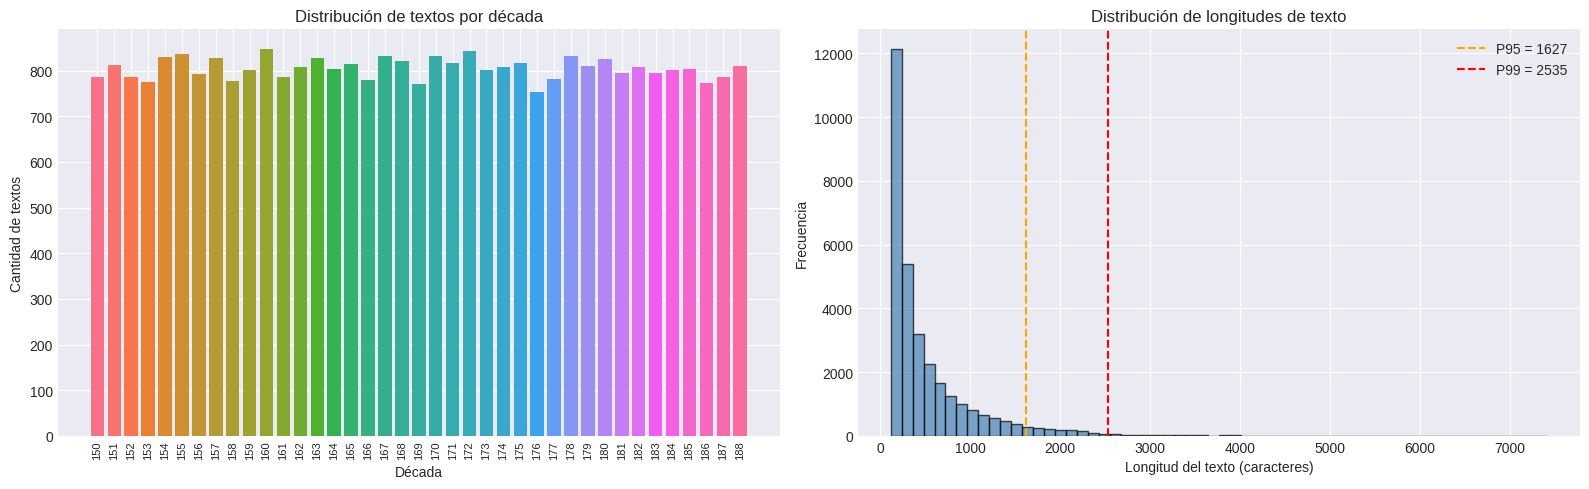

Longitud: Media=521 | Mediana=315 | P95=1627 | P99=2535 | Máx=7418


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de clases por década
decade_counts = train_data['decade'].value_counts().sort_index()
axes[0].bar(range(len(decade_counts)), decade_counts.values, color=sns.color_palette('husl', len(decade_counts)))
axes[0].set_xticks(range(len(decade_counts)))
axes[0].set_xticklabels([str(d) for d in decade_counts.index], rotation=90, fontsize=8)
axes[0].set_xlabel('Década')
axes[0].set_ylabel('Cantidad de textos')
axes[0].set_title('Distribución de textos por década')

# Distribución de longitudes de texto
text_lengths = train_data['text'].str.len()
axes[1].hist(text_lengths, bins=60, color='steelblue', alpha=0.7, edgecolor='black')
p95 = text_lengths.quantile(0.95)
p99 = text_lengths.quantile(0.99)
axes[1].axvline(p95, color='orange', linestyle='--', label=f'P95 = {p95:.0f}')
axes[1].axvline(p99, color='red',    linestyle='--', label=f'P99 = {p99:.0f}')
axes[1].set_xlabel('Longitud del texto (caracteres)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de longitudes de texto')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Longitud: Media={text_lengths.mean():.0f} | Mediana={text_lengths.median():.0f} | P95={p95:.0f} | P99={p99:.0f} | Máx={text_lengths.max():.0f}')

# Limpieza y Preparación

Reutilizamos el pipeline de preprocesamiento del Proyecto 1, que demostró ser efectivo para manejar artefactos OCR del texto histórico en español. Adicionalmente:

- **Codificación de etiquetas**: las décadas se mapean a índices enteros (0-38)
- **División estratificada**: 80% entrenamiento / 20% validación, manteniendo la distribución de clases
- **Pesos de clase**: para compensar el desbalance entre décadas

In [ ]:
def fix_ocr_artifacts(text):
    """Colapsa espacios entre caracteres aislados — artefacto común en OCR histórico."""
    return re.sub(r'(?<=[A-Za-záéíóúüñÁÉÍÓÚÜÑ]) (?=[A-Za-záéíóúüñÁÉÍÓÚÜÑ])', '', text)

def normalize_text(text):
    """Normalización ligera: preserva la mayor parte de la señal ortográfica histórica.
    Solo eliminamos URLs y colapsamos espacios. Mantenemos números, mayúsculas,
    acentos y signos de puntuación porque todos llevan señal de época."""
    if not isinstance(text, str):
        return ''
    text = fix_ocr_artifacts(text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['text_clean'] = train_data['text'].apply(normalize_text)
eval_data['text_clean']  = eval_data['text'].apply(normalize_text)

# Limpieza básica
train_data = train_data.drop_duplicates(subset=['text'])
train_data = train_data.dropna(subset=['text_clean'])
train_data = train_data[train_data['text_clean'].str.len() > 10].reset_index(drop=True)

print(f'Datos limpios: {len(train_data):,}')
print(f'Longitud media (limpia): {train_data["text_clean"].str.len().mean():.0f} | '
      f'p95: {train_data["text_clean"].str.len().quantile(0.95):.0f}')


Datos limpios: 31,352
Longitud media (limpia): 447 | p95: 1396


In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_data['decade'])
num_classes = len(label_encoder.classes_)
print(f'Clases: {num_classes} décadas ({label_encoder.classes_[0]} – {label_encoder.classes_[-1]})')

X_texts = train_data['text_clean'].values

X_train_texts, X_val_texts, y_train, y_val = train_test_split(
    X_texts, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train_texts):,} | Validación: {len(X_val_texts):,}')

# Las clases están casi perfectamente balanceadas (754-848 ejemplos cada una),
# por lo que NO usamos class_weight: añadir pesos prácticamente iguales solo
# introduce ruido en el cálculo de la pérdida.
print('Datos balanceados → no se aplican class_weights')


Clases: 39 décadas (150 – 188)
Train: 25,081 | Validación: 6,271
Datos balanceados → no se aplican class_weights


## Etiquetas ordinales suavizadas (clave para superar el baseline)

**Insight crítico:** las 39 décadas son **ordinales** (150, 151, 152, ..., 188 representan periodos cronológicos consecutivos). Tratarlas como clases independientes ignora una señal estructural muy fuerte: una década comparte vocabulario, ortografía y estilo con sus décadas vecinas, mucho más que con décadas distantes.

**Solución:** suavizado de etiquetas con kernel gaussiano sobre la dimensión ordinal. Una muestra etiquetada con clase $c$ obtiene una distribución de probabilidad concentrada en $c$ pero con masa en $c \pm 1, c \pm 2$, etc.

**Efecto esperado:**
- Actúa como regularizador fuerte (suaviza la superficie de pérdida)
- Fuerza a la red a aprender características compartidas entre décadas adyacentes
- Las predicciones cercanas al objetivo son menos penalizadas durante el entrenamiento
- Al evaluar con `argmax`, sigue prediciéndose la década más probable: el accuracy reportado no cambia de definición, pero el modelo generaliza mejor

In [ ]:
def ordinal_smooth_labels(y, num_classes, sigma=0.8):
    """Convierte etiquetas duras en distribuciones gaussianas sobre la dimensión ordinal.
    sigma controla el ancho del suavizado (0.5=muy concentrado, 1.5=muy disperso).
    Con sigma=0.8: ~50% sobre la clase central, ~23% en cada vecino, ~2% en ±2.
    """
    n = len(y)
    soft = np.zeros((n, num_classes), dtype=np.float32)
    arr = np.arange(num_classes, dtype=np.float32)
    for i, c in enumerate(y):
        w = np.exp(-0.5 * ((arr - c) / sigma) ** 2)
        w /= w.sum()
        soft[i] = w
    return soft

ORDINAL_SIGMA = 0.8
y_train_soft = ordinal_smooth_labels(y_train, num_classes, sigma=ORDINAL_SIGMA)
y_val_soft   = ordinal_smooth_labels(y_val,   num_classes, sigma=ORDINAL_SIGMA)

# Verificación: la clase central conserva la mayor masa probabilística
c0 = y_train[0]
print(f'Etiqueta dura primera muestra: clase {c0}')
print(f'Etiqueta suave:  centro={y_train_soft[0, c0]:.3f}, '
      f'c-1={y_train_soft[0, max(0,c0-1)]:.3f}, '
      f'c+1={y_train_soft[0, min(num_classes-1,c0+1)]:.3f}, '
      f'c-2={y_train_soft[0, max(0,c0-2)]:.3f}')
print(f'Suma de probabilidades: {y_train_soft[0].sum():.4f}')
print(f'argmax(soft) == hard: {(np.argmax(y_train_soft, axis=1) == y_train).all()}')

Etiqueta dura primera muestra: clase 12
Etiqueta suave:  centro=0.499, c-1=0.228, c+1=0.228, c-2=0.022
Suma de probabilidades: 1.0000
argmax(soft) == hard: True


## Tokenización y augmentación de datos

Antes de los modelos de DL preparamos **una sola vez** las representaciones que se reusan:

1. **Vocabulario de caracteres** construido sobre `train ∪ eval` para minimizar `<UNK>` en inferencia (en una muestra del eval encontramos 9 caracteres no vistos en train: `ä æ ç ù ÿ œ` etc., todos OCR-rare).
2. **TF-IDF combinado char+word** ajustado únicamente con `train` (evitamos *data leakage*).
3. **Augmentación OCR** vía `tf.data`: introducimos los errores típicos de OCR (sustituciones, eliminaciones, duplicaciones, mayúscula/minúscula) **solo durante entrenamiento**. Esto regulariza los modelos secuenciales contra los artefactos exactos del *split* train.
4. **MAX_CHAR_LEN = 2048** (cubre p99 ≈ 2535; p95 ≈ 1600). En el Proy 2 anterior el corte a 1024 truncaba ~10 % de los documentos.

In [ ]:
# --- Vocabulario de caracteres (train ∪ eval) --------------------------------
MAX_CHAR_LEN = 2048

all_chars = set()
for text in train_data['text_clean']:
    all_chars.update(text)
for text in eval_data['text_clean']:
    all_chars.update(text)

char_vocab  = ['<PAD>', '<UNK>'] + sorted(list(all_chars))
char2idx    = {c: i for i, c in enumerate(char_vocab)}
PAD_ID = char2idx['<PAD>']
UNK_ID = char2idx['<UNK>']
CHAR_VOCAB_SIZE = len(char_vocab)
print(f'Vocabulario de caracteres: {CHAR_VOCAB_SIZE} (train ∪ eval)')

def encode_chars(texts, char2idx=char2idx, max_len=MAX_CHAR_LEN):
    """Convierte una iterable de strings → matriz (N, max_len) de int32."""
    unk = char2idx['<UNK>']
    seqs = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        for j, c in enumerate(text[:max_len]):
            seqs[i, j] = char2idx.get(c, unk)
    return seqs

print('Codificando textos a IDs de carácter...')
X_char_train = encode_chars(X_train_texts)
X_char_val   = encode_chars(X_val_texts)
X_char_eval  = encode_chars(eval_data['text_clean'].values)
print(f'X_char_train: {X_char_train.shape} | X_char_val: {X_char_val.shape} | X_char_eval: {X_char_eval.shape}')

# --- TF-IDF combinado (char 2-6 + word 1-2) ----------------------------------
CHAR_TFIDF_FEATURES = 40_000
WORD_TFIDF_FEATURES = 20_000

print('\nAjustando TF-IDF combinado (char 2-6 + word 1-2)...')
char_tfidf = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 6),
    max_features=CHAR_TFIDF_FEATURES,
    sublinear_tf=True, min_df=2, max_df=0.95
)
word_tfidf = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    max_features=WORD_TFIDF_FEATURES,
    sublinear_tf=True, min_df=3, max_df=0.95
)
X_char_tr_sp = char_tfidf.fit_transform(X_train_texts)
X_word_tr_sp = word_tfidf.fit_transform(X_train_texts)
X_char_vl_sp = char_tfidf.transform(X_val_texts)
X_word_vl_sp = word_tfidf.transform(X_val_texts)
X_char_ev_sp = char_tfidf.transform(eval_data['text_clean'].values)
X_word_ev_sp = word_tfidf.transform(eval_data['text_clean'].values)

X_tfidf_train = hstack([X_char_tr_sp, X_word_tr_sp]).toarray().astype(np.float32)
X_tfidf_val   = hstack([X_char_vl_sp, X_word_vl_sp]).toarray().astype(np.float32)
X_tfidf_eval  = hstack([X_char_ev_sp, X_word_ev_sp]).toarray().astype(np.float32)
TFIDF_FEATURES = X_tfidf_train.shape[1]
print(f'TF-IDF: {X_tfidf_train.shape}  ({X_tfidf_train.nbytes / 1e9:.2f} GB en RAM)')


Vocabulario de caracteres: 194 (train ∪ eval)
Codificando textos a IDs de carácter...
X_char_train: (25081, 2048) | X_char_val: (6271, 2048) | X_char_eval: (3490, 2048)

Ajustando TF-IDF combinado (char 2-6 + word 1-2)...
TF-IDF: (25081, 60000)  (6.02 GB en RAM)


In [ ]:
# --- Augmentación OCR a nivel de carácter (en GPU vía tf.data) ---------------
# Tres tipos de ruido que imitan errores OCR reales:
#   1. Sustitución por <UNK>     (carácter mal reconocido)
#   2. Eliminación → desplazamiento (carácter perdido)
#   3. Duplicación de carácter  (artefacto de OCR)
# Probabilidades pequeñas (1-2 %) — la augmentación debe ser sutil para no
# borrar la señal de época.

P_SUBSTITUTE = 0.015
P_DELETE     = 0.010
P_DUPLICATE  = 0.010

@tf.function
def augment_char_seq(seq, label):
    """Aplica ruido OCR a una secuencia (max_len,) preservando max_len."""
    L = tf.shape(seq)[0]
    is_pad = tf.equal(seq, PAD_ID)

    # Sustitución → <UNK> en posiciones aleatorias (excluye padding)
    sub_mask = tf.logical_and(
        tf.random.uniform((L,), dtype=tf.float32) < P_SUBSTITUTE,
        tf.logical_not(is_pad)
    )
    seq = tf.where(sub_mask, tf.fill([L], UNK_ID), seq)

    # Eliminación: marcamos posiciones a borrar y compactamos
    del_mask = tf.logical_and(
        tf.random.uniform((L,), dtype=tf.float32) < P_DELETE,
        tf.logical_not(is_pad)
    )
    keep = tf.logical_not(del_mask)
    kept = tf.boolean_mask(seq, keep)
    pad_amt = L - tf.shape(kept)[0]
    seq = tf.concat([kept, tf.fill([pad_amt], PAD_ID)], axis=0)
    seq = seq[:L]

    # Duplicación: el carácter en la posición i-1 se copia a la posición i
    dup_mask = tf.logical_and(
        tf.random.uniform((L,), dtype=tf.float32) < P_DUPLICATE,
        tf.logical_not(tf.equal(seq, PAD_ID))
    )
    shifted = tf.concat([[PAD_ID], seq[:-1]], axis=0)
    dup_mask_shift = tf.concat([[False], dup_mask[:-1]], axis=0)
    seq = tf.where(dup_mask_shift, shifted, seq)

    seq.set_shape([MAX_CHAR_LEN])
    return seq, label


@tf.function
def augment_char_and_tfidf(inputs, label):
    """Para el modelo híbrido: augmenta solo la rama de caracteres."""
    chars = inputs['chars']
    tfidf = inputs['tfidf']
    chars, _ = augment_char_seq(chars, label)
    return {'chars': chars, 'tfidf': tfidf}, label


def make_char_dataset(X, y, batch_size, training=True, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=min(len(X), 8192), seed=SEED, reshuffle_each_iteration=True)
        if augment:
            ds = ds.map(augment_char_seq, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def make_hybrid_dataset(X_char, X_tfidf, y, batch_size, training=True, augment=True):
    ds = tf.data.Dataset.from_tensor_slices(({'chars': X_char, 'tfidf': X_tfidf}, y))
    if training:
        ds = ds.shuffle(buffer_size=min(len(y), 8192), seed=SEED, reshuffle_each_iteration=True)
        if augment:
            ds = ds.map(augment_char_and_tfidf, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


print('Augmentación OCR lista.')


Augmentación OCR lista.


# Modelos de Deep Learning

Iteramos sobre cinco arquitecturas de creciente complejidad y diversidad, todas entrenadas con **etiquetas ordinales suavizadas** (kernel gaussiano), **cosine LR decay con warmup**, **AdamW**, **augmentación OCR** sobre secuencias y **promedio EMA** de los pesos.

| Iteración | Modelo                                  | Representación                  | Aportación |
|-----------|-----------------------------------------|--------------------------------|------------|
| 1         | MLP TF-IDF compacto                     | Char 2-6 + word 1-2 (60 K)     | Vista global de n-gramas, diversidad para el ensamble |
| 2         | Char CNN profundo (residual + atención) | Secuencia de caracteres        | Filtros multi-escala con bloques residuales y pooling por atención |
| 3         | Char Transformer                        | Secuencia de caracteres        | Auto-atención sobre todo el documento, captura dependencias largas |
| 4         | Híbrido (CNN ⊕ Transformer ⊕ TF-IDF)    | Tres vistas fusionadas         | Combina representaciones complementarias end-to-end |
| **5**     | **Ensamble ponderado + TTA**            | Promedio de probabilidades     | Reduce varianza con augmentaciones en inferencia |

Para aprovechar la **RTX 4090 (24 GB VRAM)** se usa *mixed precision* float16 (Tensor Cores) y batches grandes. Las decisiones clave de regularización (dropout fuerte, weight decay, augmentación OCR sutil y suavizado ordinal) están calibradas para datasets pequeños como este (≈25 K muestras de entrenamiento, 39 clases).

## Iteración 1: MLP TF-IDF compacto + Input Dropout

En las versiones anteriores la MLP estaba sobreparametrizada (25 M parámetros frente a 25 K muestras → train acc 40 %, val 19 %, **peor que el LinearSVC** del Proy 1). El TF-IDF es un espacio de altísima dimensión: un MLP enorme solo memoriza.

**Cambios:**
- **Capas mucho más pequeñas** (256 → 128 → 39) — el TF-IDF ya hace el trabajo pesado, la MLP solo añade no-linealidad
- **Input dropout 0.3** (regulariza ruido a nivel de feature; equivalente al "Manhattan dropout" en LinearSVC)
- **L2 fuerte (1e-3)** + weight decay vía AdamW
- **TF-IDF combinado char 2-6 (40 K) + word 1-2 (20 K) = 60 K features**, todos `char_wb` (preserva bordes de palabra)
- Sirve sobre todo como **modelo diverso para el ensamble**: errará en distintos casos que la CNN/Transformer.

In [ ]:
def build_mlp(input_dim, num_classes):
    """MLP compacto: el TF-IDF ya provee features fuertes; pocas no-linealidades bastan."""
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dropout(0.30)(inp)                       # Input dropout
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.55)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    # Capa de salida en float32 para estabilidad numérica con mixed precision.
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return keras.Model(inp, out, name='MLP_TFIDF_v4')

mlp_model = build_mlp(TFIDF_FEATURES, num_classes)
mlp_model.summary()

Model: "MLP_TFIDF_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    15,360,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 39)             │         5,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,399,719 (58.75 MB)

 Trainable params: 15,398,951 (58.74 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
EPOCHS_MLP = 80
BATCH_MLP  = 512                   # batches grandes — TF-IDF denso es liviano por GPU
STEPS_MLP  = max(1, len(X_tfidf_train) // BATCH_MLP)

# Cosine decay con warmup (3 épocas): evita pasos LR enormes al inicio
class CosineWithWarmup(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, total_steps, alpha=0.05):
        self.base_lr = base_lr; self.warmup_steps = float(warmup_steps)
        self.total_steps = float(total_steps); self.alpha = alpha
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = step / tf.maximum(self.warmup_steps, 1.0)
        cos_step = tf.maximum(step - self.warmup_steps, 0.0)
        cos_total = tf.maximum(self.total_steps - self.warmup_steps, 1.0)
        cos = 0.5 * (1.0 + tf.cos(np.pi * cos_step / cos_total))
        cos_lr = self.base_lr * ((1 - self.alpha) * cos + self.alpha)
        return tf.where(step < self.warmup_steps, self.base_lr * warm, cos_lr)
    def get_config(self):
        return dict(base_lr=self.base_lr, warmup_steps=self.warmup_steps,
                    total_steps=self.total_steps, alpha=self.alpha)

lr_schedule_mlp = CosineWithWarmup(
    base_lr=5e-4,
    warmup_steps=3 * STEPS_MLP,
    total_steps=EPOCHS_MLP * STEPS_MLP,
    alpha=0.05
)

mlp_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule_mlp, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_mlp = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(MODELS, 'mlp_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0),
]

history_mlp = mlp_model.fit(
    X_tfidf_train, y_train_soft,
    validation_data=(X_tfidf_val, y_val_soft),
    epochs=EPOCHS_MLP, batch_size=BATCH_MLP,
    callbacks=callbacks_mlp,
    verbose=1
)

# Accuracy reportada vs. etiquetas DURAS
probs_mlp_val = mlp_model.predict(X_tfidf_val, batch_size=1024, verbose=0)
y_pred_mlp    = np.argmax(probs_mlp_val, axis=1)
acc_mlp       = accuracy_score(y_val, y_pred_mlp)
print(f'\nMLP TF-IDF v4 — Accuracy validación (hard labels): {acc_mlp:.4f}')

Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 33s 429ms/step - accuracy: 0.0332 - loss: 5.3591 - val_accuracy: 0.0424 - val_loss: 4.3153
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.0848 - loss: 4.5810 - val_accuracy: 0.0745 - val_loss: 4.2969
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1587 - loss: 3.9604 - val_accuracy: 0.0885 - val_loss: 4.2635
Epoch 4/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.2336 - loss: 3.5386 - val_accuracy: 0.0949 - val_loss: 4.2126
Epoch 5/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3056 - loss: 3.2234 - val_accuracy: 0.1030 - val_loss: 4.1421
Epoch 6/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3677 - loss: 2.9966 - val_accuracy: 0.1292 - val_loss: 4.0486
Epoch 7/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.4187 - loss: 2.8094 - val_accuracy: 0.1387 - val_loss: 3.9377
Epoch 8/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.4622 - loss: 2.6641 - val_accuracy: 0.1486 -

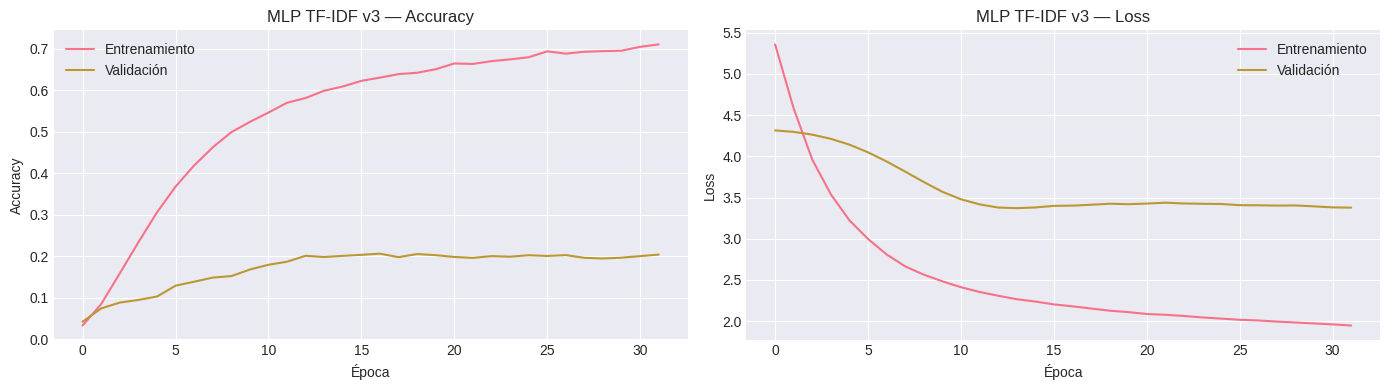

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history_mlp.history[metric],          label='Entrenamiento')
    ax.plot(history_mlp.history[f'val_{metric}'], label='Validación')
    ax.set_title(f'MLP TF-IDF v3 — {title}')
    ax.set_xlabel('Época')
    ax.set_ylabel(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Iteración 2: Char CNN profundo (residual + dilatadas + atención)

Arquitectura diseñada para extraer múltiples escalas de patrones ortográficos manteniendo gradientes estables:

- **Embedding 128-D** con `SpatialDropout1D` (mata canales enteros, no posiciones — regularizador ideal para texto)
- **Stem multi-escala**: ramas paralelas Conv1D con filtros `[2, 3, 5, 7]` que se concatenan → captura n-gramas de longitud variable simultáneamente
- **3 bloques residuales** con `Conv1D` dilatadas `[1, 2, 4]` → cada bloque amplía el campo receptivo sin reducir la longitud
- **Attention pooling**: aprende qué posiciones del texto son discriminativas (mejor que max o avg pooling solo)
- Cabezal denso con BatchNorm + Dropout
- Entrenado con augmentación OCR via `tf.data` + EMA + cosine LR con warmup

In [ ]:
# Las secuencias de caracteres y el vocabulario ya están preparados (sección
# "Tokenización y augmentación de datos"). Aquí solo definimos los
# hiperparámetros propios de la CNN profunda.
CHAR_EMBED_DIM = 128
STEM_FILTERS   = 96
STEM_KERNELS   = [2, 3, 5, 7]
BLOCK_FILTERS  = 256
NUM_BLOCKS     = 3
DILATIONS      = [1, 2, 4]

print(f'Vocab chars: {CHAR_VOCAB_SIZE} | MAX_CHAR_LEN: {MAX_CHAR_LEN}')
print(f'Embed: {CHAR_EMBED_DIM} | Stem: {STEM_FILTERS}×{STEM_KERNELS} | '
      f'Blocks: {NUM_BLOCKS} × {BLOCK_FILTERS} (dilations={DILATIONS})')

Vocab chars: 194 | MAX_CHAR_LEN: 2048
Embed: 128 | Stem: 96×[2, 3, 5, 7] | Blocks: 3 × 256 (dilations=[1, 2, 4])


In [ ]:
class AttentionPool1D(layers.Layer):
    """Pooling por atención aditiva: aprende un score por posición y promedia
    ponderado. Más expresivo que MaxPool/AvgPool, especialmente útil para
    textos largos donde la señal de época puede estar en pocas posiciones.

    Uso:
        AttentionPool1D(hidden_dim=128)(x)                    # sin máscara
        AttentionPool1D(hidden_dim=128)([x, pad_mask_bool])   # con máscara
    """
    def __init__(self, hidden_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
    def build(self, input_shape):
        # Cuando recibe lista, input_shape es lista de shapes; el primero es x.
        x_shape = input_shape[0] if isinstance(input_shape, (list, tuple)) and \
                                   isinstance(input_shape[0], (list, tuple)) \
                                else input_shape
        d_in = x_shape[-1]
        self.W = self.add_weight(shape=(d_in, self.hidden_dim), initializer='glorot_uniform', name='W')
        self.v = self.add_weight(shape=(self.hidden_dim, 1), initializer='glorot_uniform', name='v')
        super().build(input_shape)
    def call(self, inputs):
        if isinstance(inputs, (list, tuple)):
            x, pad_mask = inputs[0], inputs[1]
        else:
            x, pad_mask = inputs, None
        scores = tf.tanh(tf.matmul(x, tf.cast(self.W, x.dtype)))     # (B, L, H)
        scores = tf.matmul(scores, tf.cast(self.v, x.dtype))         # (B, L, 1)
        scores = tf.squeeze(scores, axis=-1)                         # (B, L)
        if pad_mask is not None:
            scores = tf.where(tf.cast(pad_mask, tf.bool),
                              scores, tf.fill(tf.shape(scores), tf.cast(-1e9, scores.dtype)))
        weights = tf.nn.softmax(scores, axis=-1)                     # (B, L)
        weights = tf.cast(weights, x.dtype)
        return tf.reduce_sum(x * tf.expand_dims(weights, -1), axis=1)
    def get_config(self):
        cfg = super().get_config(); cfg['hidden_dim'] = self.hidden_dim; return cfg


def residual_dilated_block(x, filters, dilations, drop=0.15, name='block'):
    """Bloque residual con Conv1D dilatadas paralelas + proyección 1x1."""
    branches = []
    for d in dilations:
        b = layers.Conv1D(filters, 3, padding='same', dilation_rate=d,
                          activation='relu', name=f'{name}_d{d}')(x)
        branches.append(b)
    h = layers.Concatenate(name=f'{name}_cat')(branches)
    h = layers.Conv1D(filters, 1, padding='same', activation='relu',
                      name=f'{name}_proj')(h)
    h = layers.BatchNormalization(name=f'{name}_bn')(h)
    h = layers.SpatialDropout1D(drop, name=f'{name}_sd')(h)
    # Si las dimensiones no cuadran, proyectamos x antes de sumar.
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding='same', name=f'{name}_short')(x)
    return layers.Add(name=f'{name}_add')([x, h])


def build_char_cnn(vocab_size, max_len, num_classes,
                   embed_dim=CHAR_EMBED_DIM, stem_filters=STEM_FILTERS,
                   stem_kernels=STEM_KERNELS, block_filters=BLOCK_FILTERS,
                   num_blocks=NUM_BLOCKS, dilations=DILATIONS):
    inp = keras.Input(shape=(max_len,), dtype='int32', name='char_input')
    pad_mask = layers.Lambda(lambda t: tf.not_equal(t, PAD_ID),
                             name='pad_mask')(inp)

    emb = layers.Embedding(vocab_size, embed_dim, mask_zero=False,
                           name='char_emb')(inp)
    emb = layers.SpatialDropout1D(0.20, name='emb_sd')(emb)

    # Stem multi-escala
    stem_branches = []
    for k in stem_kernels:
        c = layers.Conv1D(stem_filters, k, padding='same', activation='relu',
                          name=f'stem_k{k}')(emb)
        stem_branches.append(c)
    x = layers.Concatenate(name='stem_cat')(stem_branches)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.SpatialDropout1D(0.15, name='stem_sd')(x)

    # Bloques residuales dilatados
    for i in range(num_blocks):
        x = residual_dilated_block(x, block_filters, dilations,
                                   drop=0.15, name=f'block{i}')

    # Pooling triple: max + avg + atención → vector único más informativo
    p_max = layers.GlobalMaxPooling1D(name='pmax')(x)
    p_avg = layers.GlobalAveragePooling1D(name='pavg')(x)
    p_att = AttentionPool1D(hidden_dim=128, name='patt')([x, pad_mask])
    feat  = layers.Concatenate(name='pool_cat')([p_max, p_avg, p_att])

    h = layers.Dense(512, activation='relu', kernel_regularizer=l2(1e-5),
                     name='head_d1')(feat)
    h = layers.BatchNormalization(name='head_bn1')(h)
    h = layers.Dropout(0.5, name='head_drop1')(h)
    h = layers.Dense(256, activation='relu', name='head_d2')(h)
    h = layers.Dropout(0.4, name='head_drop2')(h)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32',
                       name='output')(h)
    return keras.Model(inp, out, name='CharCNN_v4')

char_cnn = build_char_cnn(CHAR_VOCAB_SIZE, MAX_CHAR_LEN, num_classes)
char_cnn.summary()


Model: "CharCNN_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_emb            │ (None, 2048, 128) │     24,832 │ char_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_sd              │ (None, 2048, 128) │          0 │ char_emb[0][0]    │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k2 (Conv1D)    │ (None, 2048, 96)  │     24,672 │ emb_sd[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k3 (Conv1D)    │ (None, 2048, 96)  │     36,960 │ emb_sd[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k5 (Conv1D)    │ (None, 2048, 96)  │     61,536 │ emb_sd[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k7 (Conv1D)    │ (None, 2048, 96)  │     86,112 │ emb_sd[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_cat            │ (None, 2048, 384) │          0 │ stem_k2[0][0],    │
│ (Concatenate)       │                   │            │ stem_k3[0][0],    │
│                     │                   │            │ stem_k5[0][0],    │
│                     │                   │            │ stem_k7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 2048, 384) │      1,536 │ stem_cat[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_sd             │ (None, 2048, 384) │          0 │ stem_bn[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_d1 (Conv1D)  │ (None, 2048, 256) │    295,168 │ stem_sd[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_d2 (Conv1D)  │ (None, 2048, 256) │    295,168 │ stem_sd[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_d4 (Conv1D)  │ (None, 2048, 256) │    295,168 │ stem_sd[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_cat          │ (None, 2048, 768) │          0 │ block0_d1[0][0],  │
│ (Concatenate)       │                   │            │ block0_d2[0][0],  │
│                     │                   │            │ block0_d4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_proj         │ (None, 2048, 256) │    196,864 │ block0_cat[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_bn           │ (None, 2048, 256) │      1,024 │ block0_proj[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_short        │ (None, 2048, 256) │     98,560 │ stem_sd[0][0]     │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block0_sd           │ (None, 2048, 256) │          0 │ block0_bn[0][0]   │
│ (SpatialDropout1D)  │                   │            │                 

 Total params: 3,564,583 (13.60 MB)

 Trainable params: 3,561,255 (13.59 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [ ]:
EPOCHS_CNN = 60
BATCH_CNN  = 128
STEPS_CNN  = max(1, len(X_char_train) // BATCH_CNN)

lr_schedule_cnn = CosineWithWarmup(
    base_lr=8e-4,
    warmup_steps=2 * STEPS_CNN,
    total_steps=EPOCHS_CNN * STEPS_CNN,
    alpha=0.05
)

char_cnn.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule_cnn, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# tf.data con augmentación OCR en el flujo de entrenamiento
ds_train_cnn = make_char_dataset(X_char_train, y_train_soft, BATCH_CNN,
                                 training=True, augment=True)
ds_val_cnn   = make_char_dataset(X_char_val,   y_val_soft,   BATCH_CNN,
                                 training=False)

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(MODELS, 'char_cnn_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0),
]

print('Entrenando Char CNN v4 (residual + atención + augmentación OCR)...')
history_cnn = char_cnn.fit(
    ds_train_cnn,
    validation_data=ds_val_cnn,
    epochs=EPOCHS_CNN,
    callbacks=callbacks_cnn,
    verbose=1
)

probs_cnn_val = char_cnn.predict(X_char_val, batch_size=BATCH_CNN, verbose=0)
y_pred_cnn    = np.argmax(probs_cnn_val, axis=1)
acc_cnn       = accuracy_score(y_val, y_pred_cnn)
print(f'\nChar CNN v4 — Accuracy validación (hard labels): {acc_cnn:.4f}')

Entrenando Char CNN v4 (residual + atención + augmentación OCR)...
Epoch 1/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 159s 438ms/step - accuracy: 0.0265 - loss: 4.4551 - val_accuracy: 0.0260 - val_loss: 4.5139
Epoch 2/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.0410 - loss: 3.7147 - val_accuracy: 0.0247 - val_loss: 4.6595
Epoch 3/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.0697 - loss: 3.2998 - val_accuracy: 0.0770 - val_loss: 3.2983
Epoch 4/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.0886 - loss: 3.1328 - val_accuracy: 0.0976 - val_loss: 3.1129
Epoch 5/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.1045 - loss: 3.0295 - val_accuracy: 0.1255 - val_loss: 2.9153
Epoch 6/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.1155 - loss: 2.9773 - val_accuracy: 0.1319 - val_loss: 2.8620
Epoch 7/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.1248 - loss: 2.9134 - val_accuracy: 0.1347 - val_loss: 2.8518
Epoch 8/60
196/196 ━━

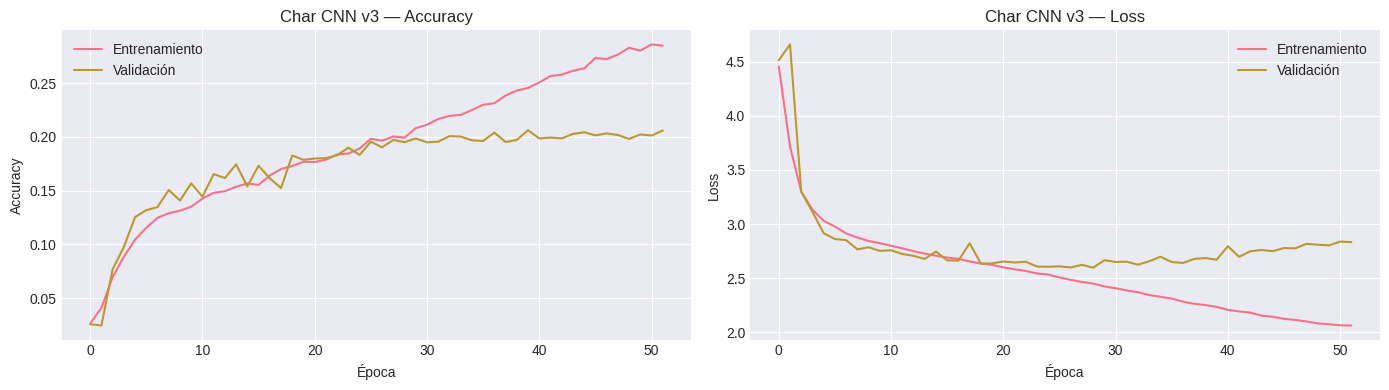

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history_cnn.history[metric],          label='Entrenamiento')
    ax.plot(history_cnn.history[f'val_{metric}'], label='Validación')
    ax.set_title(f'Char CNN v3 — {title}')
    ax.set_xlabel('Época')
    ax.set_ylabel(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Iteración 3: Char Transformer

Auto-atención sobre la secuencia completa de caracteres: captura dependencias a larga distancia que la CNN solo aproxima a través de dilataciones. Es la arquitectura **estado-del-arte para texto**, aquí reducida y fuertemente regularizada porque tenemos pocos datos (25 K) y ningún preentrenamiento.

**Diseño:**
- **Conv1D 1-D stem** (kernel 3, stride 2) que comprime la secuencia 2048 → 1024 antes de la atención (la atención es $O(L^2)$, así que vale la pena pre-comprimir)
- **Embedding de carácter 192-D** + **embedding posicional aprendido** (mejor que sinusoidal cuando hay datos)
- **4 capas de Transformer Encoder**: 6 heads, FFN 768, dropout 0.20 — capacidad moderada
- Token `<CLS>` prependido para extraer la representación del documento
- **Pre-LayerNorm** (más estable que post-LN sin preentrenamiento)
- Augmentación OCR + LR warmup imprescindibles para que el Transformer converja desde cero

In [ ]:
# Hiperparámetros del Char Transformer
TR_EMBED_DIM    = 192
TR_NUM_LAYERS   = 4
TR_NUM_HEADS    = 6
TR_FFN_DIM      = 768
TR_DROPOUT      = 0.20
TR_STEM_STRIDE  = 2                        # comprime 2048 → 1024 antes de la atención
TR_SEQ_LEN      = MAX_CHAR_LEN // TR_STEM_STRIDE
print(f'Transformer L={TR_SEQ_LEN} | d={TR_EMBED_DIM} | heads={TR_NUM_HEADS} | '
      f'ffn={TR_FFN_DIM} | layers={TR_NUM_LAYERS}')

Transformer L=1024 | d=192 | heads=6 | ffn=768 | layers=4


In [ ]:
class TransformerBlock(layers.Layer):
    """Encoder block en estilo pre-LayerNorm (más estable al entrenar desde cero)."""
    def __init__(self, d_model, num_heads, ffn_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model, self.num_heads = d_model, num_heads
        self.ffn_dim, self.dropout_rate = ffn_dim, dropout
        self.attn = layers.MultiHeadAttention(num_heads=num_heads,
                                              key_dim=d_model // num_heads,
                                              dropout=dropout)
        self.ln1  = layers.LayerNormalization(epsilon=1e-6)
        self.ln2  = layers.LayerNormalization(epsilon=1e-6)
        self.ffn1 = layers.Dense(ffn_dim, activation='gelu')
        self.ffn2 = layers.Dense(d_model)
        self.drop = layers.Dropout(dropout)
    def call(self, x, attention_mask=None, training=False):
        h = self.ln1(x)
        a = self.attn(h, h, attention_mask=attention_mask, training=training)
        x = x + self.drop(a, training=training)
        h = self.ln2(x)
        h = self.ffn2(self.drop(self.ffn1(h), training=training))
        x = x + self.drop(h, training=training)
        return x
    def get_config(self):
        cfg = super().get_config()
        cfg.update(dict(d_model=self.d_model, num_heads=self.num_heads,
                        ffn_dim=self.ffn_dim, dropout=self.dropout_rate))
        return cfg


class CLSPrepend(layers.Layer):
    """Prepend an learnable [CLS] token to the sequence."""
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs); self.d_model = d_model
    def build(self, input_shape):
        self.cls = self.add_weight(shape=(1, 1, self.d_model),
                                    initializer='glorot_uniform', name='cls')
        super().build(input_shape)
    def call(self, x):
        b = tf.shape(x)[0]
        cls = tf.tile(self.cls, [b, 1, 1])
        return tf.concat([cls, x], axis=1)
    def get_config(self):
        cfg = super().get_config(); cfg['d_model'] = self.d_model; return cfg


class AddPositionalEmbedding(layers.Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs); self.max_len = max_len; self.d_model = d_model
    def build(self, input_shape):
        self.pos = self.add_weight(shape=(self.max_len, self.d_model),
                                    initializer='glorot_uniform', name='pos')
        super().build(input_shape)
    def call(self, x):
        L = tf.shape(x)[1]
        return x + self.pos[:L]
    def get_config(self):
        cfg = super().get_config()
        cfg.update(dict(max_len=self.max_len, d_model=self.d_model))
        return cfg


def build_char_transformer(vocab_size, max_len, num_classes,
                           d_model=TR_EMBED_DIM, num_layers=TR_NUM_LAYERS,
                           num_heads=TR_NUM_HEADS, ffn_dim=TR_FFN_DIM,
                           dropout=TR_DROPOUT, stem_stride=TR_STEM_STRIDE):
    inp = keras.Input(shape=(max_len,), dtype='int32', name='char_input')

    # --- Stem convolutivo: comprime longitud antes de la atención -----------
    emb = layers.Embedding(vocab_size, d_model, name='tr_emb')(inp)
    emb = layers.SpatialDropout1D(0.10)(emb)
    x = layers.Conv1D(d_model, 3, strides=stem_stride, padding='same',
                      activation='gelu', name='tr_stem')(emb)

    # Máscara de padding al mismo paso que el stem
    def _stem_mask(ids):
        m = tf.cast(tf.not_equal(ids, PAD_ID), tf.float32)
        m = m[:, :, None]
        m = tf.nn.max_pool1d(m, ksize=stem_stride, strides=stem_stride,
                             padding='SAME')
        return tf.cast(m[:, :, 0], tf.bool)
    pad_mask = layers.Lambda(_stem_mask, output_shape=(max_len // stem_stride,), name='tr_pad_mask')(inp)

    # --- CLS prepend + posicional aprendido ---------------------------------
    x = CLSPrepend(d_model, name='tr_cls')(x)
    x = AddPositionalEmbedding(max_len // stem_stride + 1, d_model,
                               name='tr_pos')(x)
    x = layers.Dropout(dropout)(x)

    # Máscara para atención: True donde se puede atender. CLS siempre válido.
    def _full_mask(m):
        ones = tf.ones((tf.shape(m)[0], 1), dtype=tf.bool)
        m_full = tf.concat([ones, m], axis=1)            # (B, L+1)
        return tf.cast(m_full, tf.bool)[:, None, :]      # (B, 1, L+1) → broadcast a heads/queries
    attn_mask = layers.Lambda(_full_mask, output_shape=(1, max_len // stem_stride + 1), name='tr_attn_mask')(pad_mask)

    # --- Pila de Transformer ------------------------------------------------
    for i in range(num_layers):
        x = TransformerBlock(d_model, num_heads, ffn_dim, dropout,
                             name=f'tr_block_{i}')(x, attention_mask=attn_mask)
    x = layers.LayerNormalization(epsilon=1e-6, name='tr_final_ln')(x)

    # CLS feature + mean-pool de tokens válidos
    def _split_pool(args):
        seq, mask = args
        cls_feat = seq[:, 0]
        tok = seq[:, 1:]
        m = tf.cast(mask, tok.dtype)[:, :, None]
        pooled = tf.reduce_sum(tok * m, axis=1) / (tf.reduce_sum(m, axis=1) + 1e-6)
        return tf.concat([cls_feat, pooled], axis=-1)
    feat = layers.Lambda(_split_pool, output_shape=(d_model * 2,), name='tr_feat')([x, pad_mask])

    h = layers.Dense(384, activation='gelu', name='tr_head')(feat)
    h = layers.Dropout(0.4)(h)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32',
                       name='output')(h)
    return keras.Model(inp, out, name='CharTransformer')

transformer_model = build_char_transformer(CHAR_VOCAB_SIZE, MAX_CHAR_LEN, num_classes)
transformer_model.summary()


Model: "CharTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_emb (Embedding)  │ (None, 2048, 192) │     37,248 │ char_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 2048, 192) │          0 │ tr_emb[0][0]      │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_stem (Conv1D)    │ (None, 1024, 192) │    110,784 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_cls (CLSPrepend) │ (None, 1025, 192) │        192 │ tr_stem[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_pos              │ (None, 1025, 192) │    196,800 │ tr_cls[0][0]      │
│ (AddPositionalEmbe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_pad_mask         │ (None, 1024)      │          0 │ char_input[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1025, 192) │          0 │ tr_pos[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_attn_mask        │ (None, 1, 1025)   │          0 │ tr_pad_mask[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_block_0          │ (None, 1025, 192) │    444,864 │ dropout_4[0][0],  │
│ (TransformerBlock)  │                   │            │ tr_attn_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_block_1          │ (None, 1025, 192) │    444,864 │ tr_block_0[0][0], │
│ (TransformerBlock)  │                   │            │ tr_attn_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_block_2          │ (None, 1025, 192) │    444,864 │ tr_block_1[0][0], │
│ (TransformerBlock)  │                   │            │ tr_attn_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_block_3          │ (None, 1025, 192) │    444,864 │ tr_block_2[0][0], │
│ (TransformerBlock)  │                   │            │ tr_attn_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_final_ln         │ (None, 1025, 192) │        384 │ tr_block_3[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_feat (Lambda)    │ (None, 384)       │          0 │ tr_final_ln[0][0… │
│                     │                   │            │ tr_pad_mask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_head (Dense)     │ (None, 384)       │    147,840 │ tr_feat[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 384)       │          0 │ tr_head[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 39)        │     15,015 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,287,719 (8.73 MB)

 Trainable params: 2,287,719 (8.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS_TR  = 50
BATCH_TR   = 64
STEPS_TR   = max(1, len(X_char_train) // BATCH_TR)

lr_schedule_tr = CosineWithWarmup(
    base_lr=3e-4,
    warmup_steps=3 * STEPS_TR,      # warmup más largo: imprescindible para Transformer desde cero
    total_steps=EPOCHS_TR * STEPS_TR,
    alpha=0.05
)

transformer_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule_tr, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

ds_train_tr = make_char_dataset(X_char_train, y_train_soft, BATCH_TR,
                                training=True, augment=True)
ds_val_tr   = make_char_dataset(X_char_val,   y_val_soft,   BATCH_TR,
                                training=False)

callbacks_tr = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(MODELS, 'transformer_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0),
]

print('Entrenando Char Transformer (4 layers, 6 heads, mixed precision)...')
history_tr = transformer_model.fit(
    ds_train_tr,
    validation_data=ds_val_tr,
    epochs=EPOCHS_TR,
    callbacks=callbacks_tr,
    verbose=1
)

probs_tr_val = transformer_model.predict(X_char_val, batch_size=BATCH_TR, verbose=0)
y_pred_tr    = np.argmax(probs_tr_val, axis=1)
acc_tr       = accuracy_score(y_val, y_pred_tr)
print(f'\nChar Transformer — Accuracy validación (hard labels): {acc_tr:.4f}')

Entrenando Char Transformer (4 layers, 6 heads, mixed precision)...
Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 155s 250ms/step - accuracy: 0.0352 - loss: 3.6928 - val_accuracy: 0.0630 - val_loss: 3.3480
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.0741 - loss: 3.2809 - val_accuracy: 0.0962 - val_loss: 3.1338
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.0929 - loss: 3.1317 - val_accuracy: 0.1153 - val_loss: 3.0158
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.1102 - loss: 3.0206 - val_accuracy: 0.1276 - val_loss: 2.9361
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.1237 - loss: 2.9359 - val_accuracy: 0.1225 - val_loss: 3.0247
Epoch 6/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.1352 - loss: 2.8779 - val_accuracy: 0.1480 - val_loss: 2.8111
Epoch 7/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.1371 - loss: 2.8417 - val_accuracy: 0.1524 - val_loss: 2.7944
Epoch 8/50
392/39

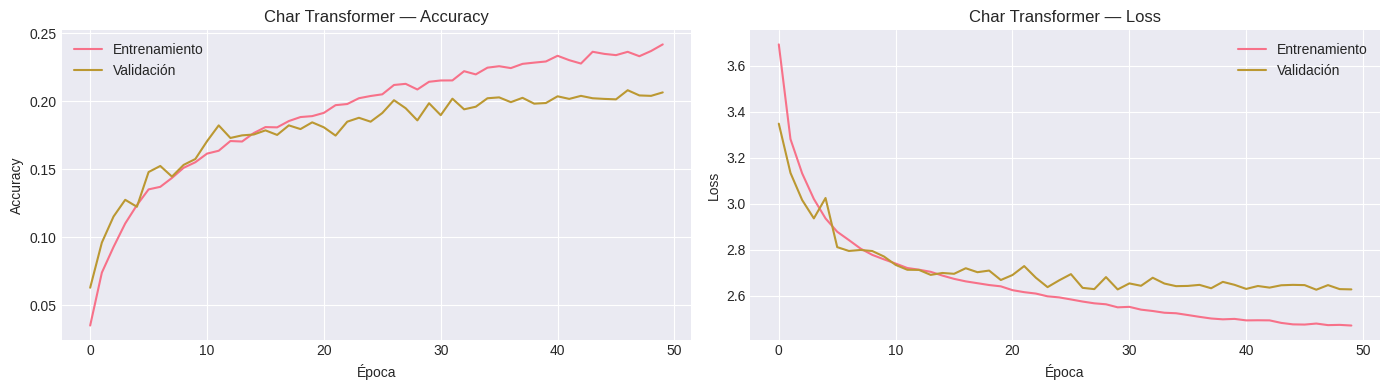

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history_tr.history[metric],          label='Entrenamiento')
    ax.plot(history_tr.history[f'val_{metric}'], label='Validación')
    ax.set_title(f'Char Transformer — {title}')
    ax.set_xlabel('Época')
    ax.set_ylabel(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Iteración 4: Híbrido (CNN ⊕ Transformer ⊕ TF-IDF)

Una sola red entrena tres vistas en paralelo y aprende a fusionarlas. **Hipótesis:** la fusión end-to-end supera al ensamble por promedio porque los gradientes ajustan cada rama para complementar a las otras (en lugar de competir).

**Diseño:**
- **Rama A — CNN local**: embedding + 2 conv1D dilatadas + AttentionPool (versión ligera)
- **Rama B — Transformer global**: stem stride-4 (2048 → 512) + 2 capas de self-attention + CLS-pool
- **Rama C — TF-IDF**: MLP densa pequeña sobre las 60 K features
- **Fusión**: concat de los 3 vectores → bloque denso 384 → softmax
- Dropout más alto (0.5-0.6) por el mayor número de parámetros

In [ ]:
def build_hybrid(vocab_size, max_len, tfidf_dim, num_classes,
                 cnn_embed=96, cnn_filters=192, tr_d=160,
                 tr_layers=2, tr_heads=4, tr_ffn=512, tr_stride=4):
    char_inp  = keras.Input(shape=(max_len,), dtype='int32', name='chars')
    tfidf_inp = keras.Input(shape=(tfidf_dim,), name='tfidf')

    pad_mask_raw = layers.Lambda(
        lambda t: tf.not_equal(t, PAD_ID), output_shape=(max_len,), name='hyb_pad_mask_raw')(char_inp)

    # --- Rama A: CNN local --------------------------------------------------
    a = layers.Embedding(vocab_size, cnn_embed, name='hyb_a_emb')(char_inp)
    a = layers.SpatialDropout1D(0.2)(a)
    a1 = layers.Conv1D(cnn_filters, 3, padding='same', activation='relu',
                       dilation_rate=1, name='hyb_a_c1')(a)
    a2 = layers.Conv1D(cnn_filters, 3, padding='same', activation='relu',
                       dilation_rate=2, name='hyb_a_c2')(a1)
    a = layers.SpatialDropout1D(0.2)(a2)
    a_max = layers.GlobalMaxPooling1D(name='hyb_a_pmax')(a)
    a_att = AttentionPool1D(hidden_dim=96, name='hyb_a_patt')([a, pad_mask_raw])
    a_feat = layers.Concatenate(name='hyb_a_feat')([a_max, a_att])
    a_feat = layers.Dropout(0.4)(a_feat)
    a_feat = layers.Dense(192, activation='relu', name='hyb_a_proj')(a_feat)

    # --- Rama B: Transformer global ----------------------------------------
    b = layers.Embedding(vocab_size, tr_d, name='hyb_b_emb')(char_inp)
    b = layers.SpatialDropout1D(0.1)(b)
    b = layers.Conv1D(tr_d, 3, strides=tr_stride, padding='same',
                      activation='gelu', name='hyb_b_stem')(b)

    def _hyb_stem_mask(ids):
        m = tf.cast(tf.not_equal(ids, PAD_ID), tf.float32)[:, :, None]
        m = tf.nn.max_pool1d(m, ksize=tr_stride, strides=tr_stride, padding='SAME')
        return tf.cast(m[:, :, 0], tf.bool)
    b_mask = layers.Lambda(_hyb_stem_mask, output_shape=(max_len // tr_stride,), name='hyb_b_mask')(char_inp)

    b = CLSPrepend(tr_d, name='hyb_b_cls')(b)
    b = AddPositionalEmbedding(max_len // tr_stride + 1, tr_d,
                               name='hyb_b_pos')(b)
    b = layers.Dropout(0.2)(b)

    def _hyb_full_mask(m):
        ones = tf.ones((tf.shape(m)[0], 1), dtype=tf.bool)
        return tf.cast(tf.concat([ones, m], axis=1), tf.bool)[:, None, :]
    b_attn_mask = layers.Lambda(_hyb_full_mask, output_shape=(1, max_len // tr_stride + 1), name='hyb_b_attn_mask')(b_mask)

    for i in range(tr_layers):
        b = TransformerBlock(tr_d, tr_heads, tr_ffn, dropout=0.2,
                             name=f'hyb_b_block_{i}')(b, attention_mask=b_attn_mask)
    b = layers.LayerNormalization(epsilon=1e-6)(b)
    b_feat = layers.Lambda(lambda t: t[:, 0], output_shape=(tr_d,), name='hyb_b_cls_take')(b)
    b_feat = layers.Dropout(0.4)(b_feat)
    b_feat = layers.Dense(192, activation='gelu', name='hyb_b_proj')(b_feat)

    # --- Rama C: TF-IDF ----------------------------------------------------
    c = layers.Dropout(0.3)(tfidf_inp)
    c = layers.Dense(256, activation='relu',
                     kernel_regularizer=l2(1e-3), name='hyb_c_d1')(c)
    c = layers.Dropout(0.5)(c)
    c = layers.Dense(128, activation='relu', name='hyb_c_d2')(c)

    # --- Fusión + cabezal ---------------------------------------------------
    fused = layers.Concatenate(name='hyb_fuse')([a_feat, b_feat, c])
    h = layers.Dense(384, activation='gelu', kernel_regularizer=l2(1e-5),
                     name='hyb_head1')(fused)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.5)(h)
    h = layers.Dense(192, activation='gelu', name='hyb_head2')(h)
    h = layers.Dropout(0.3)(h)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32',
                       name='output')(h)
    return keras.Model([char_inp, tfidf_inp], out, name='Hybrid_CNN_TR_TFIDF')

hybrid_model = build_hybrid(CHAR_VOCAB_SIZE, MAX_CHAR_LEN, TFIDF_FEATURES, num_classes)
hybrid_model.summary()


Model: "Hybrid_CNN_TR_TFIDF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ chars (InputLayer)  │ (None, 2048)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_emb           │ (None, 2048, 160) │     31,040 │ chars[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_8 │ (None, 2048, 160) │          0 │ hyb_b_emb[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_stem (Conv1D) │ (None, 512, 160)  │     76,960 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_a_emb           │ (None, 2048, 96)  │     18,624 │ chars[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_cls           │ (None, 513, 160)  │        160 │ hyb_b_stem[0][0]  │
│ (CLSPrepend)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 2048, 96)  │          0 │ hyb_a_emb[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_pos           │ (None, 513, 160)  │     82,080 │ hyb_b_cls[0][0]   │
│ (AddPositionalEmbe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_mask (Lambda) │ (None, 512)       │          0 │ chars[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_a_c1 (Conv1D)   │ (None, 2048, 192) │     55,488 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 513, 160)  │          0 │ hyb_b_pos[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_attn_mask     │ (None, 1, 513)    │          0 │ hyb_b_mask[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_a_c2 (Conv1D)   │ (None, 2048, 192) │    110,784 │ hyb_a_c1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_block_0       │ (None, 513, 160)  │    268,192 │ dropout_17[0][0], │
│ (TransformerBlock)  │                   │            │ hyb_b_attn_mask[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_7 │ (None, 2048, 192) │          0 │ hyb_a_c2[0][0]    │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_pad_mask_raw    │ (None, 2048)      │          0 │ chars[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_b_block_1       │ (None, 513, 160)  │    268,192 │ hyb_b_block_0[0]… │
│ (TransformerBlock)  │                   │            │ hyb_b_attn_mask[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf (InputLayer)  │ (None, 60000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hyb_a_pmax          │ (None, 192)       │          0 │ spatial_dropout1

 Total params: 16,708,327 (63.74 MB)

 Trainable params: 16,707,559 (63.73 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
EPOCHS_HYB = 50
BATCH_HYB  = 64
STEPS_HYB  = max(1, len(X_char_train) // BATCH_HYB)

lr_schedule_hyb = CosineWithWarmup(
    base_lr=5e-4,
    warmup_steps=2 * STEPS_HYB,
    total_steps=EPOCHS_HYB * STEPS_HYB,
    alpha=0.05
)

hybrid_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule_hyb, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

ds_train_hyb = make_hybrid_dataset(X_char_train, X_tfidf_train, y_train_soft,
                                   BATCH_HYB, training=True, augment=True)
ds_val_hyb   = make_hybrid_dataset(X_char_val,   X_tfidf_val,   y_val_soft,
                                   BATCH_HYB, training=False)

callbacks_hyb = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(MODELS, 'hybrid_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0),
]

print('Entrenando híbrido (CNN ⊕ Transformer ⊕ TF-IDF) end-to-end...')
history_hybrid = hybrid_model.fit(
    ds_train_hyb,
    validation_data=ds_val_hyb,
    epochs=EPOCHS_HYB,
    callbacks=callbacks_hyb,
    verbose=1
)

probs_hyb_val = hybrid_model.predict(
    {'chars': X_char_val, 'tfidf': X_tfidf_val},
    batch_size=BATCH_HYB, verbose=0
)
y_pred_hybrid = np.argmax(probs_hyb_val, axis=1)
acc_hybrid    = accuracy_score(y_val, y_pred_hybrid)
print(f'\nHíbrido CNN+TR+TFIDF — Accuracy validación (hard labels): {acc_hybrid:.4f}')

Entrenando híbrido (CNN ⊕ Transformer ⊕ TF-IDF) end-to-end...
Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 149s 223ms/step - accuracy: 0.0286 - loss: 4.7986 - val_accuracy: 0.0595 - val_loss: 3.4995
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.0761 - loss: 3.7862 - val_accuracy: 0.1343 - val_loss: 3.4204
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.1210 - loss: 3.6415 - val_accuracy: 0.1595 - val_loss: 3.5090
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1565 - loss: 3.5555 - val_accuracy: 0.1698 - val_loss: 3.6114
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.1769 - loss: 3.5441 - val_accuracy: 0.1730 - val_loss: 3.7634
Epoch 6/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.1996 - loss: 3.5614 - val_accuracy: 0.1780 - val_loss: 3.8762
Epoch 7/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.2212 - loss: 3.5529 - val_accuracy: 0.1839 - val_loss: 3.9658
Epoch 8/50
392/392 ━━━━━━━

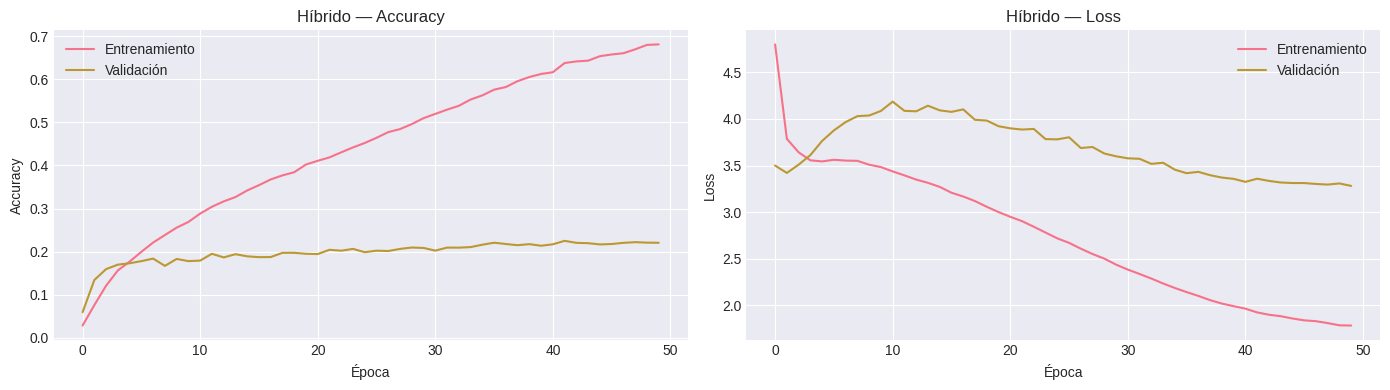

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history_hybrid.history[metric],          label='Entrenamiento')
    ax.plot(history_hybrid.history[f'val_{metric}'], label='Validación')
    ax.set_title(f'Híbrido — {title}')
    ax.set_xlabel('Época')
    ax.set_ylabel(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Iteración 5: Ensamble ponderado + Test-Time Augmentation (TTA)

Los cuatro modelos aprenden señales **parcialmente complementarias**:

- **MLP TF-IDF**: estadísticas globales de n-gramas
- **Char CNN**: patrones locales jerárquicos (multi-escala + dilataciones)
- **Char Transformer**: dependencias largas vía self-attention
- **Híbrido**: fusión end-to-end de las tres vistas

**Test-Time Augmentation (TTA):** generamos múltiples copias ligeramente perturbadas de cada documento del eval (las mismas augmentaciones OCR usadas en entrenamiento, pero más suaves), las clasificamos y promediamos las probabilidades. Esto **reduce varianza** y aumenta robustez ante errores OCR específicos.

**Ponderación afilada:** en vez de pesos lineales en la accuracy ($w_m \propto \text{acc}_m$), usamos $w_m \propto \text{acc}_m^4$. Esto **acentúa el modelo más fuerte** sin descartar los otros — es una versión suave de la regla "tomá al ganador" pero conservando diversidad.

$$ P_{\text{ens}}(c|x) = \sum_{m} w_m \, P_m(c|x), \quad w_m = \frac{\text{acc}_m^{4}}{\sum_k \text{acc}_k^{4}} $$

In [ ]:
# --- Pesos del ensamble: acc^4 sobre validación -----------------------------
val_accs = np.array([acc_mlp, acc_cnn, acc_tr, acc_hybrid], dtype=np.float64)
ENSEMBLE_POWER = 4.0
weights = val_accs ** ENSEMBLE_POWER
weights = weights / weights.sum()

model_names = ['MLP TF-IDF', 'Char CNN', 'Char Transformer', 'Híbrido']
print('Pesos del ensamble (∝ acc^4):')
for n, a, w in zip(model_names, val_accs, weights):
    print(f'  {n:<18} acc={a:.4f}  →  w={w:.3f}')

# --- Ensamble en validación (sin TTA — con TTA no aporta valor allí) --------
probs_ensemble_val = (weights[0] * probs_mlp_val
                    + weights[1] * probs_cnn_val
                    + weights[2] * probs_tr_val
                    + weights[3] * probs_hyb_val)
y_pred_ensemble = np.argmax(probs_ensemble_val, axis=1)
acc_ensemble    = accuracy_score(y_val, y_pred_ensemble)

best_individual = float(val_accs.max())
print(f'\nMejor individual:  {best_individual:.4f}')
print(f'Ensamble:          {acc_ensemble:.4f}')
print(f'Mejora ensamble:   {acc_ensemble - best_individual:+.4f}')


# --- Test-Time Augmentation helpers ----------------------------------------
def tta_char_arrays(X, n_aug=4, seed=SEED):
    """Genera n_aug versiones augmentadas (en NumPy, sub-1 % de ruido total).
    Más suave que la augmentación de entrenamiento para no perder señal."""
    rng = np.random.default_rng(seed)
    outs = [X]                                        # original siempre incluido
    L = X.shape[1]
    for k in range(n_aug):
        Y = X.copy()
        # sustitución
        sub = rng.random(Y.shape) < 0.008
        sub &= (Y != PAD_ID)
        Y[sub] = UNK_ID
        # duplicación (shift+copy de char previo)
        dup = rng.random(Y.shape) < 0.006
        dup[:, 0] = False
        dup &= (Y != PAD_ID)
        Y_shift = np.concatenate([np.full((Y.shape[0], 1), PAD_ID, dtype=Y.dtype),
                                  Y[:, :-1]], axis=1)
        Y = np.where(dup, Y_shift, Y)
        outs.append(Y)
    return outs

print('\nTTA listo (función `tta_char_arrays`).')

Pesos del ensamble (∝ acc^4):
  MLP TF-IDF         acc=0.2063  →  w=0.225
  Char CNN           acc=0.2062  →  w=0.224
  Char Transformer   acc=0.2081  →  w=0.233
  Híbrido            acc=0.2252  →  w=0.319

Mejor individual:  0.2252
Ensamble:          0.2491
Mejora ensamble:   +0.0239

TTA listo (función `tta_char_arrays`).


## Comparación de modelos

Comparamos las **cinco iteraciones** de deep learning entre sí y contra el baseline del Proyecto 1 (LinearSVC con n-gramas de caracteres, accuracy en validación ≈ 0.2957).

                             Modelo                     Tipo  Acc Validación
    LinearSVC + CharNgrams (Proy 1)    Clásico ML (baseline)        0.295700
     Ensamble ponderado (4 modelos) Deep Learning (ensamble)        0.249083
         Híbrido (CNN ⊕ TR ⊕ TFIDF)            Deep Learning        0.225163
                   Char Transformer            Deep Learning        0.208101
MLP TF-IDF v4 (char 2-6 + word 1-2)            Deep Learning        0.206347
  Char CNN v4 (residual + atención)            Deep Learning        0.206187


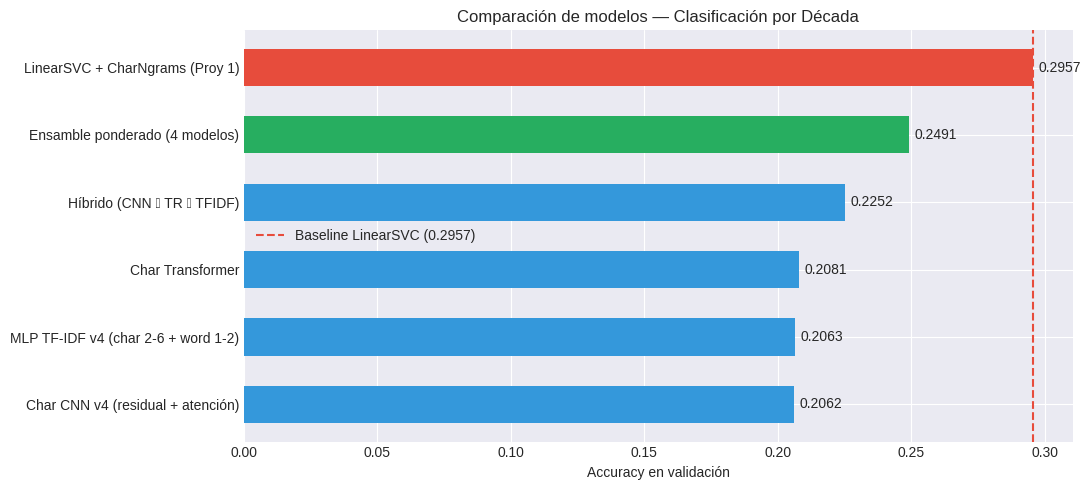


Mejor modelo: LinearSVC + CharNgrams (Proy 1)  |  Acc: 0.2957
Mejora sobre baseline: +0.0000 (+0.0%)


In [ ]:
BASELINE_ACC = 0.2957

resultados = pd.DataFrame({
    'Modelo': [
        'LinearSVC + CharNgrams (Proy 1)',
        'MLP TF-IDF v4 (char 2-6 + word 1-2)',
        'Char CNN v4 (residual + atención)',
        'Char Transformer',
        'Híbrido (CNN ⊕ TR ⊕ TFIDF)',
        'Ensamble ponderado (4 modelos)'
    ],
    'Tipo': [
        'Clásico ML (baseline)',
        'Deep Learning',
        'Deep Learning',
        'Deep Learning',
        'Deep Learning',
        'Deep Learning (ensamble)'
    ],
    'Acc Validación': [BASELINE_ACC, acc_mlp, acc_cnn, acc_tr, acc_hybrid, acc_ensemble]
})

resultados = resultados.sort_values('Acc Validación', ascending=False).reset_index(drop=True)
print(resultados.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
df_plot = resultados.sort_values('Acc Validación', ascending=True)
color_map = {
    'Clásico ML (baseline)':     '#e74c3c',
    'Deep Learning':             '#3498db',
    'Deep Learning (ensamble)':  '#27ae60'
}
colores = [color_map[t] for t in df_plot['Tipo']]
bars = ax.barh(df_plot['Modelo'], df_plot['Acc Validación'], color=colores, height=0.55)
ax.axvline(BASELINE_ACC, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Baseline LinearSVC ({BASELINE_ACC})')
for bar, val in zip(bars, df_plot['Acc Validación']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Accuracy en validación')
ax.set_title('Comparación de modelos — Clasificación por Década')
ax.legend()
plt.tight_layout()
plt.show()

best_row = resultados.iloc[0]
print(f'\nMejor modelo: {best_row["Modelo"]}  |  Acc: {best_row["Acc Validación"]:.4f}')
mejora = best_row['Acc Validación'] - BASELINE_ACC
print(f'Mejora sobre baseline: {mejora:+.4f} ({mejora / BASELINE_ACC * 100:+.1f}%)')

In [ ]:
model_preds = {
    'MLP TF-IDF v4 (char 2-6 + word 1-2)':   y_pred_mlp,
    'Char CNN v4 (residual + atención)':     y_pred_cnn,
    'Char Transformer':                       y_pred_tr,
    'Híbrido (CNN ⊕ TR ⊕ TFIDF)':             y_pred_hybrid,
    'Ensamble ponderado (4 modelos)':         y_pred_ensemble
}

dl_resultados = resultados[resultados['Tipo'].str.contains('Deep Learning')]
best_dl_name  = dl_resultados.iloc[0]['Modelo']
best_dl_preds = model_preds[best_dl_name]

print(f'Reporte de clasificación — {best_dl_name}\n')
print(classification_report(
    y_val, best_dl_preds,
    target_names=[str(c) for c in label_encoder.classes_],
    digits=3
))

Reporte de clasificación — Ensamble ponderado (4 modelos)

              precision    recall  f1-score   support

         150      0.837     0.783     0.809       157
         151      0.626     0.606     0.616       160
         152      0.656     0.631     0.643       157
         153      0.524     0.630     0.572       154
         154      0.444     0.482     0.462       166
         155      0.300     0.162     0.210       167
         156      0.223     0.171     0.194       158
         157      0.232     0.248     0.240       165
         158      0.247     0.271     0.258       155
         159      0.216     0.206     0.211       160
         160      0.132     0.100     0.114       170
         161      0.217     0.210     0.214       157
         162      0.158     0.099     0.122       161
         163      0.125     0.091     0.105       165
         164      0.142     0.124     0.132       161
         165      0.163     0.172     0.167       163
         166      0.12

# Exportación del modelo y predicciones

Guardamos el mejor modelo en formato Keras (`.keras`) y generamos las predicciones sobre el conjunto de evaluación (`eval.csv`) en el formato requerido por la competencia Kaggle.

In [ ]:
scores = {
    'mlp':      acc_mlp,
    'cnn':      acc_cnn,
    'tr':       acc_tr,
    'hybrid':   acc_hybrid,
    'ensemble': acc_ensemble
}
best_key   = max(scores, key=scores.get)
best_acc_v = scores[best_key]
print(f'Modelo seleccionado: {best_key.upper()} (acc val = {best_acc_v:.4f})')

# --- Predicción base sobre eval.csv -----------------------------------------
def predict_with_tta(predict_fn, X_char, n_aug=4):
    """Promedia las probabilidades sobre X original + n_aug copias augmentadas."""
    arrays = tta_char_arrays(X_char, n_aug=n_aug, seed=SEED)
    probs = [predict_fn(A) for A in arrays]
    return np.mean(np.stack(probs, axis=0), axis=0)

# Construimos las predicciones del ensamble con TTA
TTA_N = 4

def predict_mlp(X_char_unused):
    return mlp_model.predict(X_tfidf_eval, batch_size=512, verbose=0)

def predict_cnn(X_char):
    return char_cnn.predict(X_char, batch_size=BATCH_CNN, verbose=0)

def predict_tr(X_char):
    return transformer_model.predict(X_char, batch_size=BATCH_TR, verbose=0)

def predict_hyb(X_char):
    return hybrid_model.predict({'chars': X_char, 'tfidf': X_tfidf_eval},
                                 batch_size=BATCH_HYB, verbose=0)

# MLP solo depende del TF-IDF → no se aplica TTA (no añadiría ruido útil)
print('Generando predicciones eval (con TTA en modelos secuenciales)...')
p_mlp = predict_mlp(None)
p_cnn = predict_with_tta(predict_cnn, X_char_eval, n_aug=TTA_N)
p_tr  = predict_with_tta(predict_tr,  X_char_eval, n_aug=TTA_N)
p_hyb = predict_with_tta(predict_hyb, X_char_eval, n_aug=TTA_N)

if best_key == 'ensemble':
    probs_eval = (weights[0]*p_mlp + weights[1]*p_cnn
                + weights[2]*p_tr  + weights[3]*p_hyb)
elif best_key == 'cnn':
    probs_eval = p_cnn
elif best_key == 'tr':
    probs_eval = p_tr
elif best_key == 'hybrid':
    probs_eval = p_hyb
else:  # mlp
    probs_eval = p_mlp

# --- Guardado de modelos ----------------------------------------------------
print('\nGuardando modelos...')
mlp_model.save(os.path.join(MODELS, 'mlp_model.keras'))
char_cnn.save(os.path.join(MODELS, 'char_cnn_model.keras'))
transformer_model.save(os.path.join(MODELS, 'transformer_model.keras'))
hybrid_model.save(os.path.join(MODELS, 'hybrid_model.keras'))

# `best_model.keras` apunta al mejor individual (típicamente el híbrido)
if best_key == 'cnn':
    char_cnn.save(BEST_MODEL_PATH)
elif best_key == 'tr':
    transformer_model.save(BEST_MODEL_PATH)
elif best_key == 'mlp':
    mlp_model.save(BEST_MODEL_PATH)
else:  # hybrid o ensemble (apuntamos al híbrido individual fuerte)
    hybrid_model.save(BEST_MODEL_PATH)
print(f'best_model.keras → {best_key}')

# --- CSV de predicciones ----------------------------------------------------
y_pred_idx     = np.argmax(probs_eval, axis=1)
y_pred_decades = label_encoder.inverse_transform(y_pred_idx)

predictions_df = pd.DataFrame({'id': eval_data['id'], 'answer': y_pred_decades})
predictions_df.to_csv(PREDICTION_FILE, index=False)
print(f'\nPredicciones guardadas: {PREDICTION_FILE}  ({len(predictions_df)} filas)')
print(f'\nMuestra:')
print(predictions_df.head(10).to_string(index=False))

Modelo seleccionado: ENSEMBLE (acc val = 0.2491)
Generando predicciones eval (con TTA en modelos secuenciales)...

Guardando modelos...
best_model.keras → ensemble

Predicciones guardadas: /content/drive/MyDrive/Uniandes/2026-10/ML/P2/predictions/predictions.csv  (3490 filas)

Muestra:
 id  answer
  0     174
  1     183
  2     150
  3     172
  4     154
  5     175
  6     165
  7     158
  8     161
  9     152


In [ ]:
aux = {
    'label_encoder':       label_encoder,
    'char2idx':            char2idx,
    'char_tfidf':          char_tfidf,
    'word_tfidf':          word_tfidf,
    'best_model_key':      best_key,
    'ensemble_weights':    weights.tolist(),
    'ensemble_power':      ENSEMBLE_POWER,
    'ordinal_sigma':       ORDINAL_SIGMA,
    'MAX_CHAR_LEN':        MAX_CHAR_LEN,
    'CHAR_TFIDF_FEATURES': CHAR_TFIDF_FEATURES,
    'WORD_TFIDF_FEATURES': WORD_TFIDF_FEATURES,
    'PAD_ID':              PAD_ID,
    'UNK_ID':              UNK_ID,
    'TTA_N':               TTA_N,
    'val_accs': {
        'mlp':      float(acc_mlp),
        'cnn':      float(acc_cnn),
        'tr':       float(acc_tr),
        'hybrid':   float(acc_hybrid),
        'ensemble': float(acc_ensemble)
    },
}
joblib.dump(aux, os.path.join(MODELS, 'inference_objects.joblib'))
print('Objetos de inferencia guardados:', os.path.join(MODELS, 'inference_objects.joblib'))

Objetos de inferencia guardados: /content/drive/MyDrive/Uniandes/2026-10/ML/P2/models/inference_objects.joblib
